In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.artifacts import ArtifactStore


In [3]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

Keeping track of labels defined in other notebook:

"Experiments"
- `ANIL_MIX_SD__agg__bkgsub`
- `ANIL_AC_SD__agg__bkgsub`
- `WENJO_CE_SD__agg__bkgsub__nobkgrows`
- `ANIL_CE_SD__agg__bkgsub`

"Cal tag"

- `'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'` Anil Ce-134, Wenjo Ce-134, Anil Ac-225 and Anil Mix all had the same cal_tag

Efficiency curve

- `"ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ce-134
- `"ce134_wenjoSD_resp_200-1250keV_cpm_nCi_np_v1"` just Wenjo Ce-134
- `"ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ac-225
- `"ce134_resp_200-1250keV_cpm_nCi_np_v1"` Wenjo + Anil Ce-134

In [4]:
store = ArtifactStore(repo_root / "artifacts")

# Testing Ground Truth `.json`

In [5]:
exp_id = "ANIL_MIX_SD__agg__bkgsub"

truth = store.load_ground_truth(exp_id)  # e.g: exp_id = "ANIL_MIX_SD__agg__bkgsub"
truth_labels = truth["labels"]

# Example:
truth_ce = truth_labels["125:3.906"]["ce134"]["value"]
truth_ce_sigma = truth_labels["125:3.906"]["ce134"].get("sigma")

print(f'Ce ground truth for 125:3.906 nCi sample (in Bq): {truth_ce} Bq')
print(f'Uncertainty on the above measurement (in Bq): {truth_ce_sigma}')

Ce ground truth for 125:3.906 nCi sample (in Bq): 4625.0 Bq
Uncertainty on the above measurement (in Bq): None


# Initialize `runs`
- `runs` is basically a Table of Contents of all the MLE results you've performed and saved
- It contains no results on its own, but points to real payloads:
   - the `.JSON` estimates produced by MLE
   - the (optional) `.NPZ` arrays produced by MLE

In [6]:
exp_id = "ANIL_MIX_SD__agg__bkgsub"

runs = store.mle_runs_table(exp_id)  # ALWAYS a DataFrame
print('shape',runs.shape)
runs.head()

shape (1604, 12)


,activity_units,eff_models,experiment_id,fit_success,label,method_tag,nll2,npz_exists,roi_keV,run_id,saved_at,templates
0,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T00:07:10.929099+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
1,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T19:02:50.556427+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
2,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T19:02:52.769048+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
3,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T19:03:42.028449+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...
4,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,1.953:3.906,poisson_mle_v1,770.764356,True,"[200, 1250]",mle_poisson_v1__cdd64ee04a,2026-02-09T23:47:27.901192+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...


# DEBUG: Zoom into a single row from `runs` to debug and test

In [7]:
### More things you can do with Pandas (for reference):
# df = df[df["method_tag"] == "poisson_mle_v1"] # Filter based on value in a column
# In this case, filter based on estimation method used. This will be very useful when I introduce another estimation method like `cut-and-count` to the pipeline 

# target_ce_eff = "ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"
# df = df[df["eff_models"].apply(lambda d: isinstance(d, dict) and d.get("ce134") == target_ce_eff)] # Filter based on value in a column
# In this case, filter based on Ce efficiency model used (Identified with a unique tag)

# df = df.sort_values(["label", "saved_at"])
# does some bullshit

In [8]:
zoom_in_runs = runs.iloc[[0]] # `.iloc[[0]]` returns a row as a Pandas DataFrame object

print(f'runs.shape: {runs.shape}')
print(f'zoom_in_runs.shape: {zoom_in_runs.shape}')
print(f'type(zoom_in_runs): {type(zoom_in_runs)}')
zoom_in_runs[["label", "run_id", "saved_at", "fit_success", "nll2"]].head(10)

runs.shape: (1604, 12)
zoom_in_runs.shape: (1, 12)
type(zoom_in_runs): <class 'pandas.core.frame.DataFrame'>


,label,run_id,saved_at,fit_success,nll2
0,125:3.906,mle_poisson_v1__98cc2e1f0a,2026-02-09T00:07:10.929099+00:00,True,432.623603


### Returning MLE estimates

In [9]:
zoom_in_row = zoom_in_runs.iloc[0] # `.iloc[0]` returns a row as a Pandas Series object
row0_label, row0_run_id = zoom_in_row["label"], zoom_in_row["run_id"]

row0_est = store.load_mle_estimate(exp_id, row0_label, run_id=row0_run_id)

print('MLE results from the first row of `runs`:')
print(f'Estimated activities (Bq): {row0_est.activities_bq}')
print(f'Hessian uncertainties (Bq): {row0_est.uncertainties_bq}')

MLE results from the first row of `runs`:
Estimated activities (Bq): {'ac225': 178.74612612475627, 'ce134': 4421.916068971171}
Hessian uncertainties (Bq): {'ac225': 9.51572353682097, 'ce134': 12.526713799789562}


### Checking if `NPZ` arrays exist for this row

In [10]:
if not zoom_in_row["npz_exists"]:
    raise RuntimeError("This run has no saved fit arrays (npz). Re-save with fit_arrays=fit.")
else:
    print('This run has npz arrays saved. You can plot next.')

This run has npz arrays saved. You can plot next.


C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


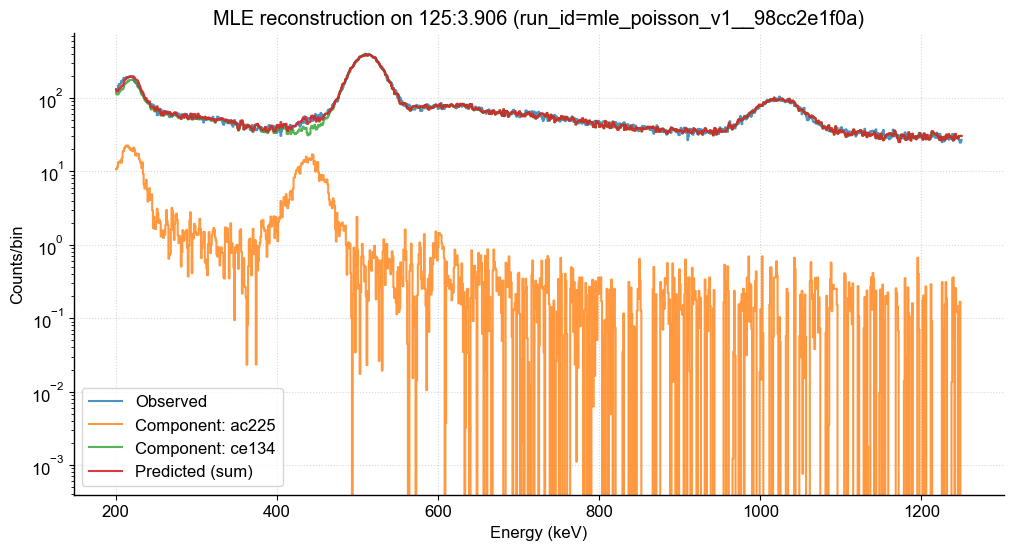

In [11]:
arr = store.load_mle_fit_arrays(exp_id, row0_label, run_id=row0_run_id)

x = arr["x_keV"]
y_obs = arr["y_obs"]
y_hat = arr["y_hat"]

plt.figure()
plt.step(x, y_obs, where="mid", label="Observed", alpha=0.8)

# plot components if present
for k in sorted(arr.keys()):
    if k.startswith("comp__"):
        iso = k.replace("comp__", "")
        plt.step(x, arr[k], where="mid", label=f"Component: {iso}", alpha=0.8)

plt.step(x, y_hat, where="mid", label="Predicted (sum)", alpha=0.9)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts/bin")
plt.legend()
plt.title(f"MLE reconstruction on {row0_label} (run_id={row0_run_id})")
plt.show()


### End DEBUG

# Follow pointers in `runs`: Flatten, Extract results, Visualize

In [12]:
def flatten_mle_runs_df(df):
    df = df.copy()

    def get_template(df_row, iso, key):
        t = df_row.get("templates")
        if isinstance(t, dict):
            ti = t.get(iso)
            if isinstance(ti, dict):
                return ti.get(key)
        return None

    def get_eff(df_row, iso):
        e = df_row.get("eff_models")
        if isinstance(e, dict):
            return e.get(iso)
        return None

    # Template provenance
    df["ce_template_label"] = df.apply(lambda r: get_template(r, "ce134", "label"), axis=1)
    df["ac_template_label"] = df.apply(lambda r: get_template(r, "ac225", "label"), axis=1)

    df["ce_template_exp_id"] = df.apply(lambda r: get_template(r, "ce134", "experiment_id"), axis=1)
    df["ac_template_exp_id"] = df.apply(lambda r: get_template(r, "ac225", "experiment_id"), axis=1)

    df["ce_cal_tag"] = df.apply(lambda r: get_template(r, "ce134", "cal_tag"), axis=1)
    df["ac_cal_tag"] = df.apply(lambda r: get_template(r, "ac225", "cal_tag"), axis=1)

    # Efficiency model names
    df["ce_eff_name"] = df.apply(lambda r: get_eff(r, "ce134"), axis=1)
    df["ac_eff_name"] = df.apply(lambda r: get_eff(r, "ac225"), axis=1)

    return df
    

def get_activity(row, iso):
    est = store.load_mle_estimate(row["experiment_id"], row["label"], run_id=row["run_id"])
    return est.activities_bq.get(iso)

In [13]:
runs_flat = flatten_mle_runs_df(runs)

runs_flat[[
    "label", "run_id",
    "ce_template_label", "ac_template_label",
    "ce_eff_name", "ac_eff_name",
    "roi_keV", "method_tag"
]].head()


,label,run_id,ce_template_label,ac_template_label,ce_eff_name,ac_eff_name,roi_keV,method_tag
0,125:3.906,mle_poisson_v1__98cc2e1f0a,125,3.90625,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,"[200, 1250]",poisson_mle_v1
1,125:3.906,mle_poisson_v1__98cc2e1f0a,125,3.90625,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,"[200, 1250]",poisson_mle_v1
2,125:3.906,mle_poisson_v1__98cc2e1f0a,125,3.90625,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,"[200, 1250]",poisson_mle_v1
3,125:3.906,mle_poisson_v1__98cc2e1f0a,125,3.90625,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,"[200, 1250]",poisson_mle_v1
4,1.953:3.906,mle_poisson_v1__cdd64ee04a,1.95312,1.95312,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1,"[200, 1250]",poisson_mle_v1


In [14]:
runs_flat

,activity_units,eff_models,experiment_id,fit_success,label,method_tag,nll2,npz_exists,roi_keV,run_id,saved_at,templates,ce_template_label,ac_template_label,ce_template_exp_id,ac_template_exp_id,ce_cal_tag,ac_cal_tag,ce_eff_name,ac_eff_name
0,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T00:07:10.929099+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,125,3.90625,ANIL_CE_SD__agg__bkgsub,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1
1,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T19:02:50.556427+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,125,3.90625,ANIL_CE_SD__agg__bkgsub,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1
2,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T19:02:52.769048+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,125,3.90625,ANIL_CE_SD__agg__bkgsub,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1
3,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,125:3.906,poisson_mle_v1,432.623603,True,"[200, 1250]",mle_poisson_v1__98cc2e1f0a,2026-02-09T19:03:42.028449+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,125,3.90625,ANIL_CE_SD__agg__bkgsub,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1
4,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,1.953:3.906,poisson_mle_v1,770.764356,True,"[200, 1250]",mle_poisson_v1__cdd64ee04a,2026-02-09T23:47:27.901192+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,1.95312,1.95312,ANIL_CE_SD__agg__bkgsub,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1599,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,7.8125:3.906,poisson_mle_v1,519.157506,True,"[200, 1250]",mle_poisson_v1__ee4312648e,2026-02-11T20:01:30.910765+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,7.8125,3.90625,ANIL_CE_SD__agg__bkgsub,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1
1600,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,7.8125:3.906,poisson_mle_v1,487.273116,True,"[200, 1250]",mle_poisson_v1__fd9a0792e9,2026-02-11T20:01:30.924719+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,7.8125,31.25,ANIL_CE_SD__agg__bkgsub,ANIL_AC_SD__agg__bkgsub,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1,ce134_resp_200-1250keV_cpm_nCi_np_v1,ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1
1601,nci,{'ac225': 'ac225_anilSD_resp_200-1250keV_cpm_n...,ANIL_MIX_SD__agg__bkgsub,True,7.8125:3.906,poisson_mle_v1,479.002859,True,"[200, 1250]",mle_poisson_v1__d8f3ec46d2,2026-02-11T20:01:30.937404+00:00,{'ac225': {'cal_tag': 'peakfit_v1_xmin200_snr1...,7.

In [15]:
runs_flat["ce134_activity_bq"] = runs_flat.apply(lambda r: get_activity(r, "ce134"), axis=1)
runs_flat["ac225_activity_bq"] = runs_flat.apply(lambda r: get_activity(r, "ac225"), axis=1)

In [16]:
runs_flat["ce134_activity_bq"]

0       4421.916069
1       4421.916069
2       4421.916069
3       4421.916069
4         78.146165
           ...     
1599     284.342199
1600     286.757396
1601     285.799548
1602     286.295672
1603     286.080949
Name: ce134_activity_bq, Length: 1604, dtype: float64

In [17]:
runs_flat["ac225_activity_bq"]

0       178.746126
1       178.746126
2       178.746126
3       178.746126
4       152.065176
           ...    
1599    161.471654
1600    156.884820
1601    158.703913
1602    157.761697
1603    158.169488
Name: ac225_activity_bq, Length: 1604, dtype: float64

In [18]:
# fixed_ac_template = runs_flat["ac_template_label"].unique()[0]  # or pick explicitly
# print(f'the Ac template is {fixed_ac_template} nCi')

# # Narrow down the subset of runs to those where Ac template is `fixed_ac_template` nCi (e.g: '3.90625' nCi) with algorithm "poisson_mle_v1"
# sub = runs_flat[ 
#     (runs_flat["ac_template_label"] == fixed_ac_template) &
#     (runs_flat["method_tag"] == "poisson_mle_v1")
# ]

# # This `pivot_table` generates the basic data structure of the sensitivity heat map
# heat = sub.pivot_table(
#     index="label",                 # X-axis / rows = mixed samples
#     columns="ce_template_label",   # Y-axis / columns = Ce template choices
#     values="ce134_activity_bq",       # cell = estimated Ce activity
#     aggfunc="mean"                 # if duplicates exist ... Oh?
# )

# plt.figure(figsize=(10, 6))
# sns.heatmap(heat, cmap="viridis")
# plt.xlabel("Ce Template Label")
# plt.ylabel("Mixed Sample Label")
# plt.title(f"Estimated Ce Activity (Bq), Ac template fixed = {fixed_ac_template}")
# plt.tight_layout()
# plt.show()

In [19]:
def percent_dev_and_sigma(est_bq, est_sigma_bq, truth_bq, truth_sigma_bq=None):
    if est_bq is None or truth_bq is None or truth_bq == 0:
        return (np.nan, np.nan)
    dev = 100.0 * (est_bq - truth_bq) / truth_bq

    # sigma propagation
    terms = []
    if est_sigma_bq is not None and np.isfinite(est_sigma_bq):
        terms.append((est_sigma_bq / truth_bq) ** 2)

    if truth_sigma_bq is not None and np.isfinite(truth_sigma_bq) and truth_sigma_bq != 0:
        terms.append(((est_bq * truth_sigma_bq) / (truth_bq ** 2)) ** 2)

    sig = 100.0 * np.sqrt(np.sum(terms)) if terms else np.nan
    return dev, sig

# def (exp_id, ISO, truth): #If I were to functionalize the loop `for _, r in runs_flat.iterrows():`

In [20]:
### Generate `percent_dev` and `percent_dev_sigma` for Ce-134 in Dataframe `runs_flat`!
# Generating percent deviation is run-agnostic: every run, no matter what config, will have a percent deviation from stated ground truth

exp_id = "ANIL_MIX_SD__agg__bkgsub"

ce134_devs = []
ce134_sigs = []
ce134_est_sig_vals = []

ISO = "ce134"

for _, r in runs_flat.iterrows():
    label = r["label"]
    run_id = r["run_id"]

    est = store.load_mle_estimate(exp_id, label, run_id=run_id)

    est_bq = est.activities_bq.get(ISO)
    est_sigma_bq = None
    if est.uncertainties_bq is not None:
        est_sigma_bq = est.uncertainties_bq.get(ISO)

    # truth lookup
    t = truth['labels'].get(label, {}).get(ISO, None)
    if t is None:
        dev, sig = (np.nan, np.nan)
    else:
        truth_bq = t.get("value")
        truth_sigma_bq = t.get("sigma", None)
        dev, sig = percent_dev_and_sigma(est_bq, est_sigma_bq, truth_bq, truth_sigma_bq)

    # est_vals.append(est_bq)
    ce134_est_sig_vals.append(est_sigma_bq)
    ce134_devs.append(dev)
    ce134_sigs.append(sig)

# runs_flat["est_bq"] = est_vals
runs_flat[f"{ISO}_est_sigma_bq"] = ce134_est_sig_vals
runs_flat[f"{ISO}_percent_dev"] = ce134_devs
runs_flat[f"{ISO}_percent_dev_sigma"] = ce134_sigs


### Generate columns `percent_dev` and `percent_dev_sigma` for Ac-225 in Dataframe `runs_flat`!
ISO = "ac225"

ac225_devs = []
ac225_sigs = []
ac225_est_sig_vals = []

for _, r in runs_flat.iterrows():
    label = r["label"]
    run_id = r["run_id"]

    est = store.load_mle_estimate(exp_id, label, run_id=run_id)

    est_bq = est.activities_bq.get(ISO)
    est_sigma_bq = None
    if est.uncertainties_bq is not None:
        est_sigma_bq = est.uncertainties_bq.get(ISO)

    # truth lookup
    t = truth['labels'].get(label, {}).get(ISO, None)
    if t is None:
        dev, sig = (np.nan, np.nan)
    else:
        truth_bq = t.get("value")
        truth_sigma_bq = t.get("sigma", None)
        dev, sig = percent_dev_and_sigma(est_bq, est_sigma_bq, truth_bq, truth_sigma_bq)

    # est_vals.append(est_bq)
    ac225_est_sig_vals.append(est_sigma_bq)
    ac225_devs.append(dev)
    ac225_sigs.append(sig)

# runs_flat["est_bq"] = est_vals
runs_flat[f"{ISO}_est_sigma_bq"] = ac225_est_sig_vals
runs_flat[f"{ISO}_percent_dev"] = ac225_devs
runs_flat[f"{ISO}_percent_dev_sigma"] = ac225_sigs

# Viz test #1
- Test Ce model sensitivity on estimates of Ce-134 and Ac-225 acitivities in mixed sample MLE
- Assumptions:
    - Fixed Ac model: *"Ac template is 3.90625 nCi"*
    - Efficiency models used
        - `"ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ce-134
        - `"ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ac-225
    - NOT using merged Ce efficiency!



the Ac template is 3.90625 nCi
Displaying the percent deviation of MLE estimates on ce134


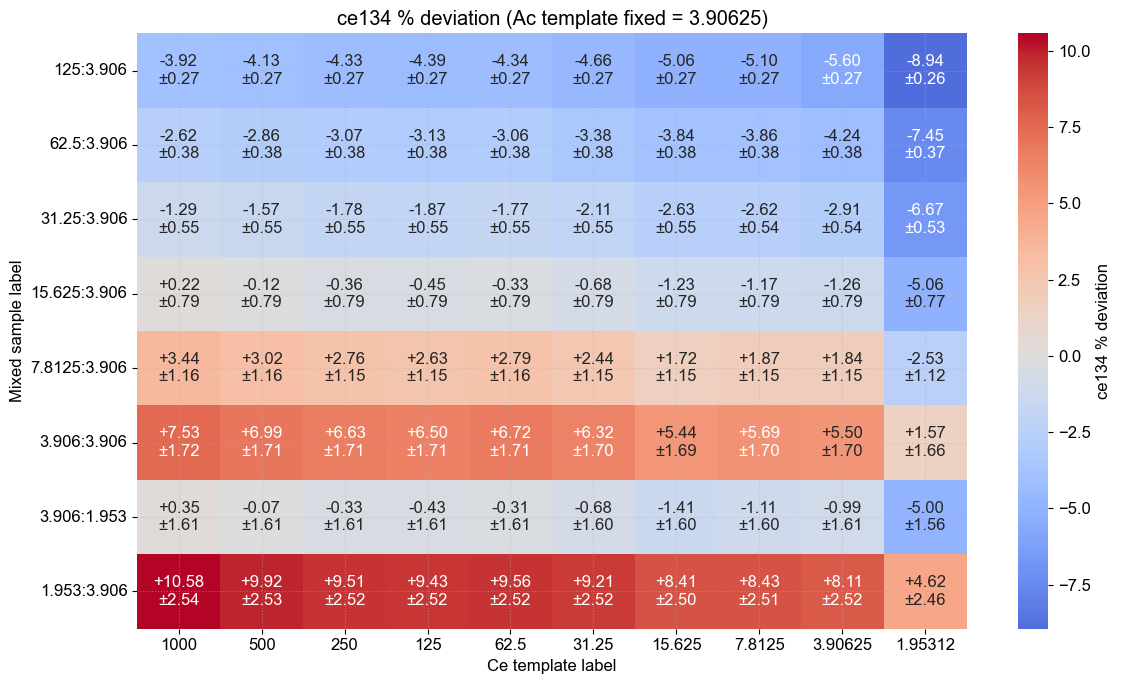

In [21]:
# seaborn method 
ISO = "ce134"

fixed_ac_template = runs_flat["ac_template_label"].unique()[0]  # or pick explicitly
print(f'the Ac template is {fixed_ac_template} nCi')

# Choose which isotope we’re evaluating
print(f'Displaying the percent deviation of MLE estimates on {ISO}')

# Narrow down the subset of runs to those where Ac template is `fixed_ac_template` nCi (e.g: '3.90625' nCi) with algorithm "poisson_mle_v1"
sub = runs_flat[ 
    (runs_flat["ac_template_label"] == fixed_ac_template) &
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ce_eff_name'] == 'ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1') &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1')
]
### If I ever were to run more MLE, I might have to add more filters to make sure I'm accessing/plotting the same subset of runs

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ce_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ce_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["125:3.906", "62.5:3.906", "31.25:3.906", "15.625:3.906", "7.8125:3.906", "3.906:3.906","3.906:1.953", "1.953:3.906"]
x_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"
                
plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    cbar_kws={"label": f"{ISO} % deviation"}
)
ax.set_xlabel("Ce template label")
ax.set_ylabel("Mixed sample label")
ax.set_title(f"{ISO} % deviation (Ac template fixed = {fixed_ac_template})")
plt.tight_layout()
plt.show()

the Ac template is 3.90625 nCi
Displaying the percent deviation of MLE estimates on ac225


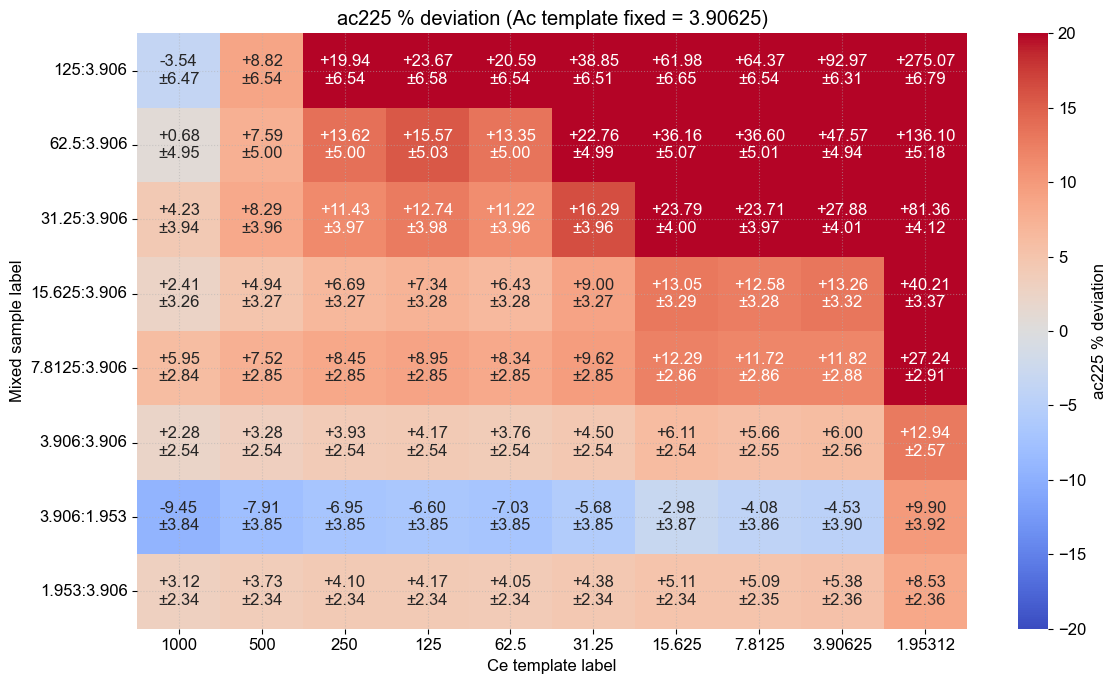

In [22]:
# seaborn method 
ISO = "ac225"

fixed_ac_template = runs_flat["ac_template_label"].unique()[0]  # or pick explicitly
print(f'the Ac template is {fixed_ac_template} nCi')

# Choose which isotope we’re evaluating
print(f'Displaying the percent deviation of MLE estimates on {ISO}')

# Narrow down the subset of runs to those where Ac template is `fixed_ac_template` nCi (e.g: '3.90625' nCi) with algorithm "poisson_mle_v1"
sub = runs_flat[ 
    (runs_flat["ac_template_label"] == fixed_ac_template) &
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ce_eff_name'] == 'ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1') &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1')
]
### If I ever were to run more MLE, I might have to add more filters to make sure I'm accessing/plotting the same subset of runs

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ce_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ce_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["125:3.906", "62.5:3.906", "31.25:3.906", "15.625:3.906", "7.8125:3.906", "3.906:3.906","3.906:1.953", "1.953:3.906"]
x_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"
                
vmin, vmax = -20, 20   # cap color scale

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": f"{ISO} % deviation"}
)
ax.set_xlabel("Ce template label")
ax.set_ylabel("Mixed sample label")
ax.set_title(f"{ISO} % deviation (Ac template fixed = {fixed_ac_template})")
plt.tight_layout()
plt.show()


# Viz test 2
- Test Ce model sensitivity on estimates of Ce-134 and Ac-225 acitivities in mixed sample MLE
- Assumptions:
    - Fixed Ac model: *"Ac template is 3.90625 nCi"*
    - Efficiency models used
        - `"ce134_resp_200-1250keV_cpm_nCi_np_v1"` merged Anil+Wenjo Ce-134
        - `"ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ac-225
    - Using the merged Ce efficiency!


the Ac template is 3.90625 nCi
Displaying the percent deviation of MLE estimates on ce134


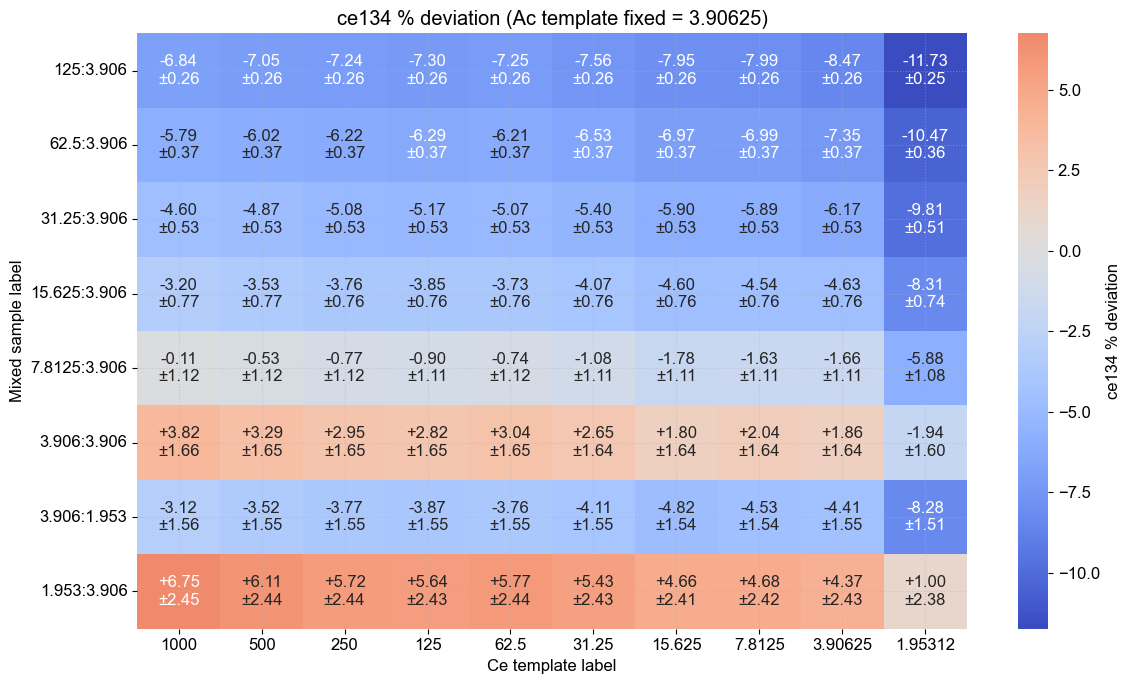

In [23]:
# seaborn method 
ISO = "ce134"

fixed_ac_template = runs_flat["ac_template_label"].unique()[0]  # or pick explicitly
print(f'the Ac template is {fixed_ac_template} nCi')

# Choose which isotope we’re evaluating
print(f'Displaying the percent deviation of MLE estimates on {ISO}')

# Narrow down the subset of runs to those where Ac template is `fixed_ac_template` nCi (e.g: '3.90625' nCi) with algorithm "poisson_mle_v1"
sub = runs_flat[ 
    (runs_flat["ac_template_label"] == fixed_ac_template) &
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ce_eff_name'] == 'ce134_resp_200-1250keV_cpm_nCi_np_v1') &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1')
]
### If I ever were to run more MLE, I might have to add more filters to make sure I'm accessing/plotting the same subset of runs

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ce_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ce_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["125:3.906", "62.5:3.906", "31.25:3.906", "15.625:3.906", "7.8125:3.906", "3.906:3.906","3.906:1.953", "1.953:3.906"]
x_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"
                
plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    cbar_kws={"label": f"{ISO} % deviation"}
)
ax.set_xlabel("Ce template label")
ax.set_ylabel("Mixed sample label")
ax.set_title(f"{ISO} % deviation (Ac template fixed = {fixed_ac_template})")
plt.tight_layout()
plt.show()

the Ac template is 3.90625 nCi
Displaying the percent deviation of MLE estimates on ac225


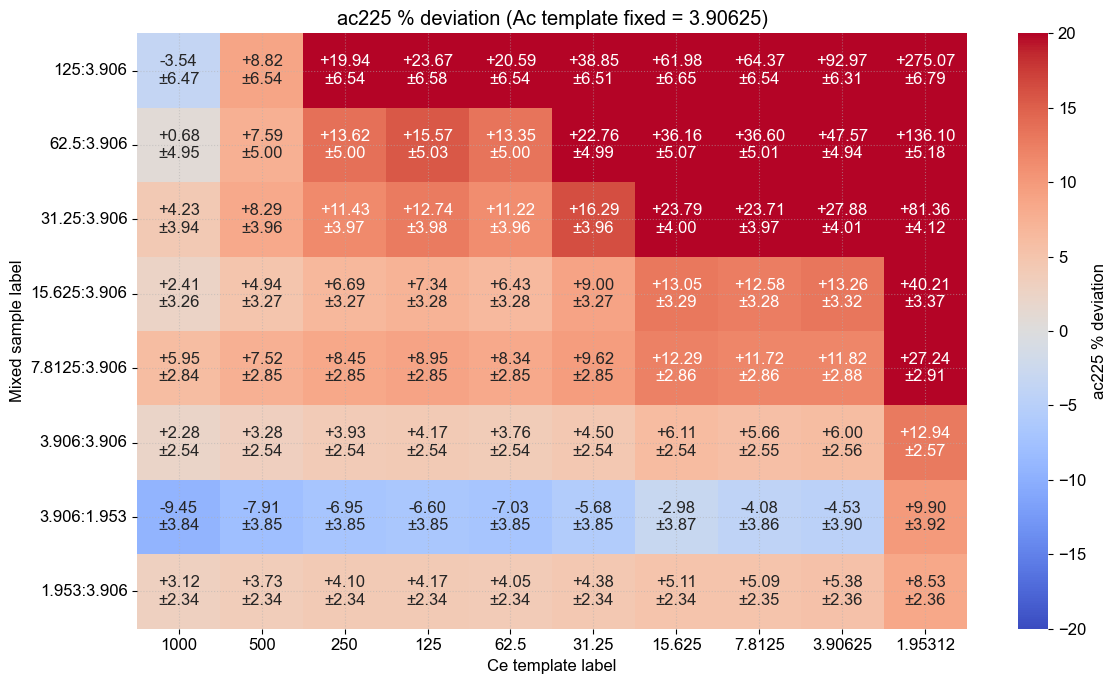

In [24]:
# seaborn method 
ISO = "ac225"

fixed_ac_template = runs_flat["ac_template_label"].unique()[0]  # or pick explicitly
print(f'the Ac template is {fixed_ac_template} nCi')

# Choose which isotope we’re evaluating
print(f'Displaying the percent deviation of MLE estimates on {ISO}')

# Narrow down the subset of runs to those where Ac template is `fixed_ac_template` nCi (e.g: '3.90625' nCi) with algorithm "poisson_mle_v1"
sub = runs_flat[ 
    (runs_flat["ac_template_label"] == fixed_ac_template) &
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ce_eff_name'] == 'ce134_resp_200-1250keV_cpm_nCi_np_v1') &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1')
]
### If I ever were to run more MLE, I might have to add more filters to make sure I'm accessing/plotting the same subset of runs

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ce_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ce_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["125:3.906", "62.5:3.906", "31.25:3.906", "15.625:3.906", "7.8125:3.906", "3.906:3.906","3.906:1.953", "1.953:3.906"]
x_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"
                
vmin, vmax = -20, 20   # cap color scale

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": f"{ISO} % deviation"}
)
ax.set_xlabel("Ce template label")
ax.set_ylabel("Mixed sample label")
ax.set_title(f"{ISO} % deviation (Ac template fixed = {fixed_ac_template})")
plt.tight_layout()
plt.show()


In [25]:
fixed_ac_template_list = runs_flat["ac_template_label"].unique()[2]
fixed_ac_template_list

'1000'

# Viz test 2
- Test Ce model sensitivity on estimates of Ce-134 and Ac-225 acitivities in mixed sample MLE
- à la Caravaca, choose the fixed template with the highest statistics: 1000 nCi
- Assumptions:
    - Fixed Ac model: *"Ac template is 1000 nCi"*
    - Efficiency models used
        - `"ce134_resp_200-1250keV_cpm_nCi_np_v1"` merged Anil+Wenjo Ce-134
        - `"ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ac-225
    - Using the merged Ce efficiency!

the Ac template is 1000 nCi
Displaying the percent deviation of MLE estimates on ce134


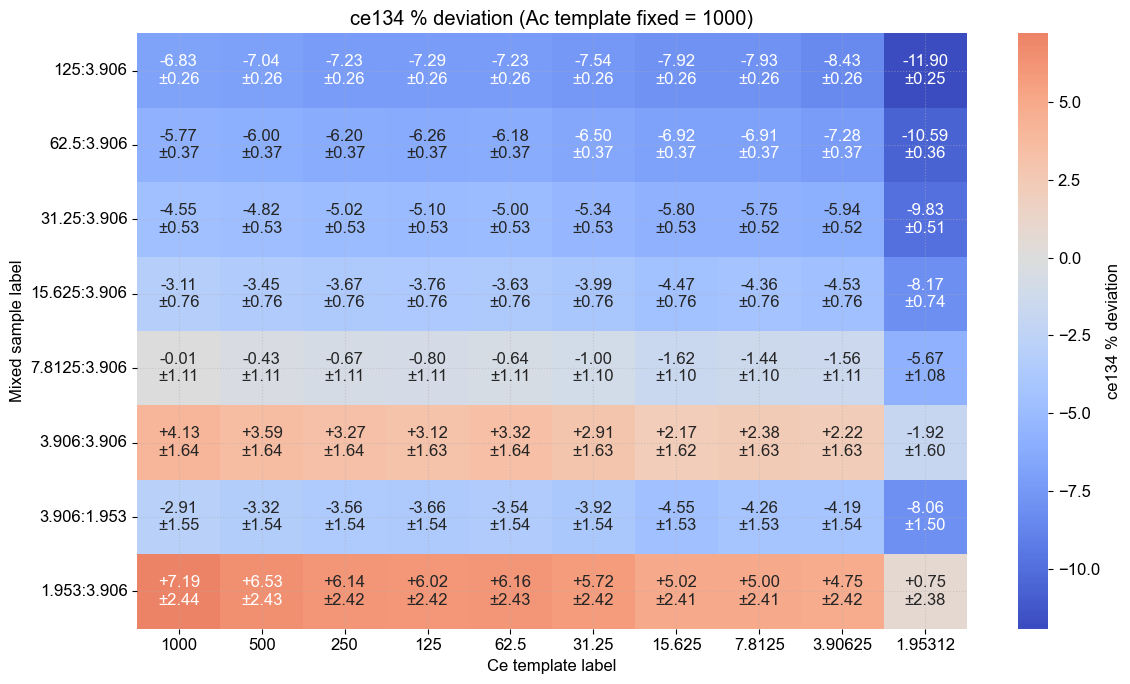

In [26]:
# seaborn method 
ISO = "ce134"

# fixed_ac_template = runs_flat["ac_template_label"].unique()[2]  # or pick explicitly
fixed_ac_template = '1000' #nCi
print(f'the Ac template is {fixed_ac_template} nCi')

# Choose which isotope we’re evaluating
print(f'Displaying the percent deviation of MLE estimates on {ISO}')

# Narrow down the subset of runs to those where Ac template is `fixed_ac_template` nCi (e.g: '3.90625' nCi) with algorithm "poisson_mle_v1"
sub = runs_flat[ 
    (runs_flat["ac_template_label"] == fixed_ac_template) &
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ce_eff_name'] == 'ce134_resp_200-1250keV_cpm_nCi_np_v1') &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1')
]
### If I ever were to run more MLE, I might have to add more filters to make sure I'm accessing/plotting the same subset of runs

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ce_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ce_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["125:3.906", "62.5:3.906", "31.25:3.906", "15.625:3.906", "7.8125:3.906", "3.906:3.906","3.906:1.953", "1.953:3.906"]
x_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"
                
plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    cbar_kws={"label": f"{ISO} % deviation"}
)
ax.set_xlabel("Ce template label")
ax.set_ylabel("Mixed sample label")
ax.set_title(f"{ISO} % deviation (Ac template fixed = {fixed_ac_template})")
plt.tight_layout()
plt.show()

the Ac template is 1000 nCi
Displaying the percent deviation of MLE estimates on ac225


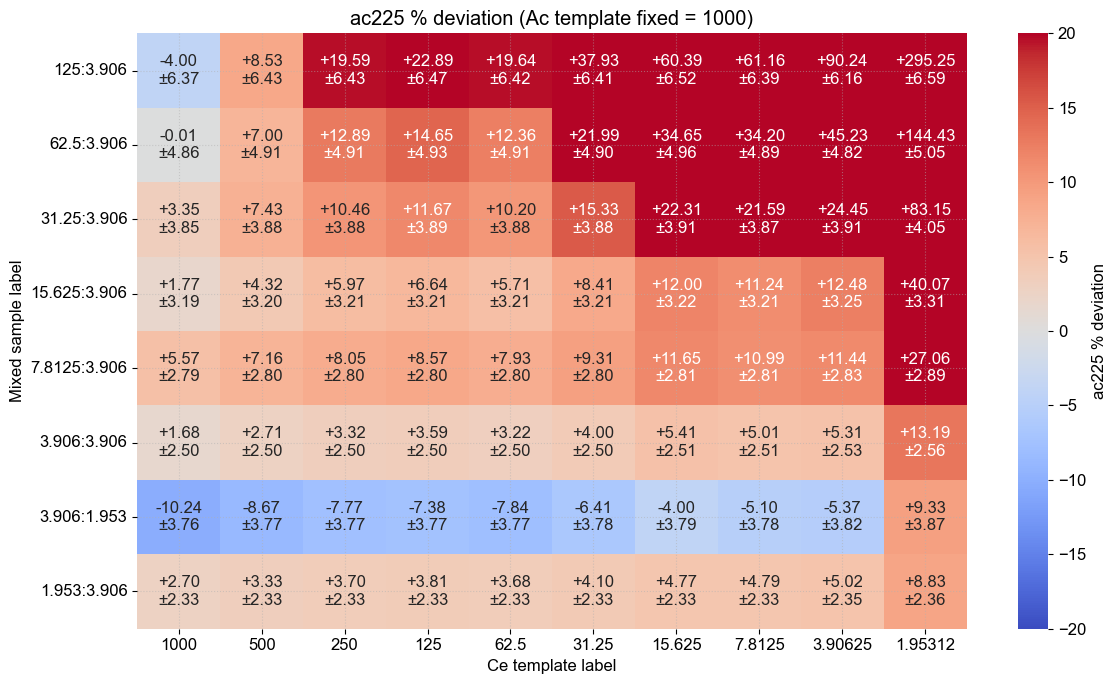

In [27]:
# seaborn method 
ISO = "ac225"

# fixed_ac_template = runs_flat["ac_template_label"].unique()[2]  # or pick explicitly
fixed_ac_template = '1000' #nCi
print(f'the Ac template is {fixed_ac_template} nCi')

# Choose which isotope we’re evaluating
print(f'Displaying the percent deviation of MLE estimates on {ISO}')

# Narrow down the subset of runs to those where Ac template is `fixed_ac_template` nCi (e.g: '3.90625' nCi) with algorithm "poisson_mle_v1"
sub = runs_flat[ 
    (runs_flat["ac_template_label"] == fixed_ac_template) &
    (runs_flat["method_tag"] == "poisson_mle_v1") &
    (runs_flat['ce_eff_name'] == 'ce134_resp_200-1250keV_cpm_nCi_np_v1') &
    (runs_flat['ac_eff_name'] == 'ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1')
]
### If I ever were to run more MLE, I might have to add more filters to make sure I'm accessing/plotting the same subset of runs

val = sub.pivot_table(
    index="label",                  # X-axis / rows = mixed samples
    columns="ce_template_label",    # Y-axis / columns = Ce template choices
    values=f"{ISO}_percent_dev",           # cell = percent deviation on Ce activity (determined from `percent_dev_and_sigma`)
    aggfunc="mean"                  # if duplicates exist ... Oh?
)

sig = sub.pivot_table(
    index="label",
    columns="ce_template_label",
    values=f"{ISO}_percent_dev_sigma",
    aggfunc="mean"
)

y_order = ["125:3.906", "62.5:3.906", "31.25:3.906", "15.625:3.906", "7.8125:3.906", "3.906:3.906","3.906:1.953", "1.953:3.906"]
x_order = ["1000", "500", "250", "125", "62.5", "31.25", "15.625", "7.8125", "3.90625", "1.95312"]

val = val.reindex(index=y_order, columns=x_order)
sig = sig.reindex(index=y_order, columns=x_order)

annot = val.copy().astype(object)

for i in range(val.shape[0]):
    for j in range(val.shape[1]):
        v = val.iat[i, j]
        s = sig.iat[i, j] if sig is not None else np.nan

        if not np.isfinite(v):
            annot.iat[i, j] = ""
        else:
            if np.isfinite(s):
                annot.iat[i, j] = f"{v:+.2f}\n±{s:.2f}"
            else:
                annot.iat[i, j] = f"{v:+.2f}"
                
vmin, vmax = -20, 20   # cap color scale

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    val,
    annot=annot,
    fmt="",              # IMPORTANT: fmt empty because annot is strings
    center=0,            # percent deviation: center at 0
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": f"{ISO} % deviation"}
)
ax.set_xlabel("Ce template label")
ax.set_ylabel("Mixed sample label")
ax.set_title(f"{ISO} % deviation (Ac template fixed = {fixed_ac_template})")
plt.tight_layout()
plt.show()


# Load in CutCount estimations

In [32]:
exp_mix = exp_id
df_cc = store.cutcount_runs_table(exp_mix)

df_cc["ce_model_type"] = df_cc["eff_models"].apply(
    lambda d: d.get("ce", {}).get("type") if isinstance(d, dict) else None
)
df_cc["ce_model_name"] = df_cc["eff_models"].apply(
    lambda d: d.get("ce", {}).get("name") if isinstance(d, dict) else None
)
df_cc["ac_model_type"] = df_cc["eff_models"].apply(
    lambda d: d.get("ac", {}).get("type") if isinstance(d, dict) else None
)
df_cc["ac_model_name"] = df_cc["eff_models"].apply(
    lambda d: d.get("ac", {}).get("name") if isinstance(d, dict) else None
)

# arr = store.load_cutcount_fit_arrays(exp_mix, mix_label, run_id=some_run_id)

In [ ]:
end

NameError: name 'end' is not defined

In [33]:
display(df_cc)

,activity_units,eff_models,experiment_id,label,method_tag,npz_exists,roi_keV,run_id,saved_at,templates,ce_model_type,ce_model_name,ac_model_type,ac_model_name
0,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v2,True,"[200.0, 1250.0]",cutcount_ceac_v2__619eb94c8e,2026-02-17T04:39:36.751441+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...,linear,ce134_win1022_counts60s_v2,linear,ac225_win_counts60s_v2
1,Bq,"{'ac': {'name': 'ac225_win_counts60s_v2', 'typ...",ANIL_MIX_SD__agg__bkgsub,1.953:3.906,cutcount_ceac_v2,True,"[200.0, 1250.0]",cutcount_ceac_v2__1ec517b76c,2026-02-17T04:42:05.234913+00:00,{'ce134': {'cal_tag': 'peakfit_v1_xmin200_snr1...,nonparalyzable,ce134_win1022_counts60s_v2,nonparalyzable,ac225_win_counts60s_v2


In [ ]:





# filter
sub = df_cc[df_cc["ce_model_name"] == "ce134_win1022_counts60s_v2"]

# sort by Ac model
sub_sorted = sub.sort_values(["ac_model_name", "saved_at"])
sub_sorted.head()


In [ ]:
# matplotlib method

def heatmap2d_with_unc(arr_color: np.ndarray,
                       arr_sigma: np.ndarray | None = None,
                       vmin=-20, vmax=20,
                       cmap='viridis',
                       fmt_val="{:+.2f}",
                       fmt_sig="{:.2f}",
                       nan_text="",
                       xlabels=None,
                       ylabels=None,
                       title=None):
    im = plt.imshow(arr_color, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    for i in range(arr_color.shape[0]):
        for j in range(arr_color.shape[1]):
            v = arr_color[i, j]
            if not np.isfinite(v):
                label = nan_text
            else:
                if arr_sigma is None:
                    label = fmt_val.format(v)
                else:
                    s = arr_sigma[i, j]
                    if np.isfinite(s):
                        label = f"{fmt_val.format(v)}\n±{fmt_sig.format(s)}"
                    else:
                        label = fmt_val.format(v)

            plt.text(j, i, label, ha="center", va="center", color="w", fontsize=10)

    plt.colorbar(im)

    if xlabels is not None:
        plt.xticks(np.arange(len(xlabels)), xlabels, rotation=45, ha="right")
    if ylabels is not None:
        plt.yticks(np.arange(len(ylabels)), ylabels)

    if title:
        plt.title(title)

    plt.tight_layout()

# call

val = heat_dev = val  # from earlier pivot
sig = sig             # from earlier pivot

arr_color = val.to_numpy()
arr_sigma = sig.to_numpy()

xlabels = list(val.columns)
ylabels = list(val.index)

plt.figure(figsize=(12, 7))
heatmap2d_with_unc(
    arr_color,
    arr_sigma=arr_sigma,
    vmin=-20, vmax=20,
    cmap="coolwarm",
    xlabels=xlabels,
    ylabels=ylabels,
    title=f"{ISO} % deviation (Ac fixed = {fixed_ac_template})"
)
plt.show()
